# Ekstraksi EMNIST ByClass ke Gambo_Balanced

Notebook ini mengekstrak gambar alfabet dari `emnist-byclass-train.csv` lalu menyimpannya ke struktur dataset:

```
Dataset/Gambo_Balanced/
├── Train/Normal/
├── Validation/Normal/
└── Test/Normal/
```

dengan aturan berikut:

* **Hanya alfabet** (`A-Z`, `a-z`) — digit `0-9` dibuang
* **Split per huruf** untuk mencegah data leakage antar subset
* **3-way split:** Train / Validation / Test
* **Penamaan file mengikuti format dataset baru**
* **Index file melanjutkan file yang sudah ada**
* **Seed acak tetap** (`42`) agar hasil reproducible
* **Orientasi EMNIST diperbaiki** menggunakan transpose (`.T`)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import re
import random
from collections import defaultdict

# =========================================================
# Reproducibility
# =========================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f'Random seed set to: {SEED}')

Random seed set to: 42


## 1. Load Mapping Label (ASCII)

Load file mapping EMNIST untuk menghubungkan:

- `label integer` → `ASCII code`
- `ASCII code` → `karakter alfabet`

Kemudian dilakukan filtering agar hanya karakter alfabet (`A-Z`, `a-z`) yang diproses.

Digit (`0-9`) akan dibuang karena tidak digunakan pada dataset `Gambo_Balanced`.

In [2]:
# =========================================================
# Load EMNIST Mapping
# =========================================================
mapping_path = os.path.join(
    'Dataset',
    'emnist-byclass-mapping.txt'
)

df_mapping = pd.read_csv(
    mapping_path,
    sep=' ',
    header=None,
    names=['label', 'ascii_code']
)

# =========================================================
# Mapping:
# label_id -> ascii_code
# =========================================================
label_to_ascii = dict(
    zip(
        df_mapping['label'],
        df_mapping['ascii_code']
    )
)

# =========================================================
# Mapping:
# label_id -> character
# =========================================================
label_to_char = {
    label_id: chr(ascii_code)
    for label_id, ascii_code
    in label_to_ascii.items()
}

# =========================================================
# Filter:
# Hanya alfabet (A-Z, a-z)
# =========================================================
alpha_labels = {
    label_id: char
    for label_id, char
    in label_to_char.items()
    if char.isalpha()
}

# =========================================================
# Statistik Mapping
# =========================================================
total_classes = len(label_to_char)
total_alpha = len(alpha_labels)
total_digits = total_classes - total_alpha

print('=' * 60)
print('EMNIST LABEL MAPPING')
print('=' * 60)

print(f'Total kelas EMNIST : {total_classes}')
print(f'Kelas alfabet      : {total_alpha}')
print(f'Kelas digit dibuang: {total_digits}')

# =========================================================
# Preview Mapping
# =========================================================
print('\nContoh mapping alfabet:')

preview_items = list(alpha_labels.items())[:10]

for label_id, char in preview_items:
    ascii_code = label_to_ascii[label_id]

    print(
        f'  Label {label_id:>2} '
        f'-> ASCII {ascii_code:>3} '
        f'-> "{char}"'
    )

EMNIST LABEL MAPPING
Total kelas EMNIST : 62
Kelas alfabet      : 52
Kelas digit dibuang: 10

Contoh mapping alfabet:
  Label 10 -> ASCII  65 -> "A"
  Label 11 -> ASCII  66 -> "B"
  Label 12 -> ASCII  67 -> "C"
  Label 13 -> ASCII  68 -> "D"
  Label 14 -> ASCII  69 -> "E"
  Label 15 -> ASCII  70 -> "F"
  Label 16 -> ASCII  71 -> "G"
  Label 17 -> ASCII  72 -> "H"
  Label 18 -> ASCII  73 -> "I"
  Label 19 -> ASCII  74 -> "J"


## 2. Load CSV EMNIST ByClass

Load dataset `emnist-byclass-train.csv` yang berisi:

- kolom pertama → label karakter
- 784 kolom berikutnya → piksel gambar (`28×28`)

Setiap baris merepresentasikan satu gambar handwritten character.

Dataset dibaca menggunakan `dtype=np.uint8` untuk menghemat penggunaan RAM karena nilai piksel hanya berada pada rentang `0-255`.

Setelah data dipisahkan menjadi:
- `labels`
- `pixels`

DataFrame utama akan dihapus dari memori untuk efisiensi.

In [3]:
# =========================================================
# Load EMNIST ByClass CSV
# =========================================================
csv_path = os.path.join(
    'Dataset',
    'emnist-byclass-train.csv'
)

print('=' * 60)
print('LOADING EMNIST CSV')
print('=' * 60)

print(f'Loading file:')
print(f'  {csv_path}')

# =========================================================
# Read CSV
# =========================================================
df = pd.read_csv(
    csv_path,
    header=None,
    dtype=np.uint8
)

# =========================================================
# Dataset Shape
# =========================================================
rows, cols = df.shape

print('\nDataset loaded successfully.')
print(f'Total samples : {rows:,}')
print(f'Total columns : {cols}')

# =========================================================
# Column Structure
# =========================================================
print('\nColumn structure:')
print('  Column 0       -> Label')
print('  Column 1-784   -> Pixel values')

# =========================================================
# Split:
# labels & pixels
# =========================================================
labels = df.iloc[:, 0].values

pixels = df.iloc[:, 1:].values

print('\nArray shapes:')
print(f'  labels : {labels.shape}')
print(f'  pixels : {pixels.shape}')

# =========================================================
# Pixel Validation
# =========================================================
print('\nPixel statistics:')
print(f'  Min pixel value : {pixels.min()}')
print(f'  Max pixel value : {pixels.max()}')

# =========================================================
# Memory Cleanup
# =========================================================
del df

print('\nDataFrame deleted from RAM.')

LOADING EMNIST CSV
Loading file:
  Dataset\emnist-byclass-train.csv

Dataset loaded successfully.
Total samples : 697,932
Total columns : 785

Column structure:
  Column 0       -> Label
  Column 1-784   -> Pixel values

Array shapes:
  labels : (697932,)
  pixels : (697932, 784)

Pixel statistics:
  Min pixel value : 0
  Max pixel value : 255

DataFrame deleted from RAM.


## 3. Filter Hanya Alfabet (Buang Digit 0-9)

Dataset EMNIST ByClass mengandung:
- digit (`0-9`)
- huruf uppercase (`A-Z`)
- huruf lowercase (`a-z`)

Pada pipeline ini hanya karakter alfabet yang digunakan untuk kelas `Normal`.

Langkah ini akan:

1. Memfilter hanya label alfabet
2. Menghapus seluruh digit
3. Mengurangi ukuran dataset
4. Menyiapkan data untuk proses split Train / Validation / Test

Setelah filtering selesai:
- array label digit akan dibuang dari memori
- hanya data alfabet yang dipertahankan

In [4]:
# =========================================================
# Filter:
# Hanya alfabet (A-Z, a-z)
# =========================================================

print('=' * 60)
print('FILTER ALFABET')
print('=' * 60)

# Set label alfabet
alpha_label_set = set(alpha_labels.keys())

# =========================================================
# Mask:
# True jika label termasuk alfabet
# =========================================================
mask = np.isin(
    labels,
    list(alpha_label_set)
)

# =========================================================
# Filter labels & pixels
# =========================================================
alpha_labels_arr = labels[mask]

alpha_pixels = pixels[mask]

# =========================================================
# Statistik Filtering
# =========================================================
total_before = len(labels)
total_after = len(alpha_labels_arr)
total_removed = total_before - total_after

print(f'Total sample sebelum filter : {total_before:,}')
print(f'Total sample alfabet        : {total_after:,}')
print(f'Total digit dibuang         : {total_removed:,}')

# =========================================================
# Persentase alfabet
# =========================================================
alpha_ratio = (
    total_after / total_before
) * 100

print(f'\nPersentase alfabet retained: {alpha_ratio:.2f}%')

# =========================================================
# Distribusi per karakter
# =========================================================
print('\nContoh distribusi karakter:')

unique_alpha, counts_alpha = np.unique(
    alpha_labels_arr,
    return_counts=True
)

preview_limit = 10

for label_id, count in zip(
    unique_alpha[:preview_limit],
    counts_alpha[:preview_limit]
):
    char = label_to_char[int(label_id)]

    print(
        f'  "{char}" '
        f'(Label {label_id:>2}) '
        f': {count:,} gambar'
    )

# =========================================================
# Memory Cleanup
# =========================================================
del labels
del pixels
del mask

print('\nOriginal arrays deleted from RAM.')

FILTER ALFABET
Total sample sebelum filter : 697,932
Total sample alfabet        : 352,897
Total digit dibuang         : 345,035

Persentase alfabet retained: 50.56%

Contoh distribusi karakter:
  "A" (Label 10) : 6,407 gambar
  "B" (Label 11) : 3,878 gambar
  "C" (Label 12) : 10,094 gambar
  "D" (Label 13) : 4,562 gambar
  "E" (Label 14) : 4,934 gambar
  "F" (Label 15) : 9,182 gambar
  "G" (Label 16) : 2,517 gambar
  "H" (Label 17) : 3,152 gambar
  "I" (Label 18) : 11,946 gambar
  "J" (Label 19) : 3,762 gambar

Original arrays deleted from RAM.


## 4. Visualisasi Sample (Verifikasi Orientasi)

EMNIST ByClass menyimpan gambar dalam format flatten (`784 pixel`) sehingga perlu direkonstruksi kembali menjadi image 2D.

Tahap ini digunakan untuk:

- memverifikasi gambar berhasil direkonstruksi dengan benar
- memastikan orientasi karakter tidak terbalik
- melihat variasi handwriting alfabet
- melakukan sanity check sebelum proses export PNG

Catatan:
- Resolusi gambar tetap original EMNIST (`28×28`)
- Tidak dilakukan resize/interpolasi
- `.reshape(28,28)` hanya merekonstruksi bentuk asli gambar
- `.T` digunakan untuk memperbaiki orientasi EMNIST

VISUALISASI SAMPLE EMNIST
Total pixel per image : 784
Auto detected size    : 28x28


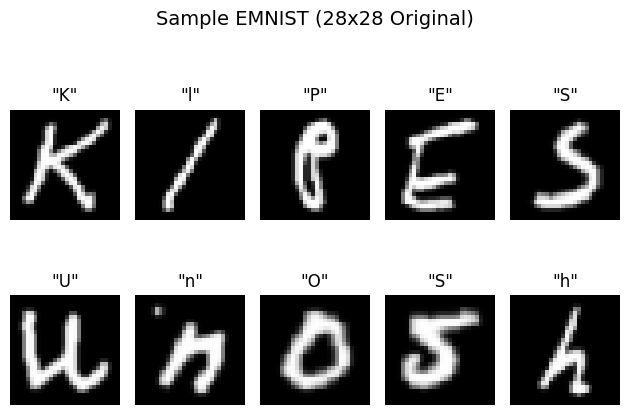

In [5]:
# =========================================================
# Visualisasi Sample EMNIST (Auto Detect Resolution)
# =========================================================

print('=' * 60)
print('VISUALISASI SAMPLE EMNIST')
print('=' * 60)

NUM_SAMPLES = 10

sample_indices = np.random.choice(
    len(alpha_labels_arr),
    NUM_SAMPLES,
    replace=False
)

# =========================================================
# Auto detect image size
# =========================================================
num_pixels = alpha_pixels.shape[1]

img_size = int(np.sqrt(num_pixels))

print(f'Total pixel per image : {num_pixels}')
print(f'Auto detected size    : {img_size}x{img_size}')

fig, axes = plt.subplots(2, 5)

fig.suptitle(
    f'Sample EMNIST ({img_size}x{img_size} Original)',
    fontsize=14
)

for i, ax in enumerate(axes.flatten()):

    idx = sample_indices[i]

    # =====================================================
    # Reconstruct original image
    # =====================================================
    img = alpha_pixels[idx].reshape(img_size, img_size)

    # =====================================================
    # Fix EMNIST orientation
    # =====================================================
    img = img.T

    label_id = int(alpha_labels_arr[idx])

    char = label_to_char[label_id]

    ax.imshow(
        img,
        cmap='gray',
        interpolation='nearest'
    )

    ax.set_title(f'"{char}"')

    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Konfigurasi Path & Scan Index Terakhir

Memindai file yang sudah ada di `Gambo_EMNIST` untuk menentukan index awal penamaan.

In [6]:
BASE = 'Dataset'
TRAIN_DST = os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Normal')
TEST_DST = os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Normal')
SPLIT_RATIO = 0.8

def get_max_index_per_letter(folder):
    max_idx = defaultdict(int)
    if not os.path.exists(folder):
        return max_idx
    for f in os.listdir(folder):
        m = re.match(r'^([A-Za-z])[-_](\d+)\.png$', f)
        if m:
            letter = m.group(1)
            idx = int(m.group(2))
            if idx > max_idx[letter]:
                max_idx[letter] = idx
    return max_idx

train_max = get_max_index_per_letter(TRAIN_DST)
test_max = get_max_index_per_letter(TEST_DST)

before_train = len(os.listdir(TRAIN_DST)) if os.path.exists(TRAIN_DST) else 0
before_test = len(os.listdir(TEST_DST)) if os.path.exists(TEST_DST) else 0

print(f'Train/Normal saat ini: {before_train:,} file')
print(f'Test/Normal saat ini:  {before_test:,} file')
print(f'Huruf terlacak di Train: {len(train_max)}')
print(f'Huruf terlacak di Test:  {len(test_max)}')

Train/Normal saat ini: 39,334 file
Test/Normal saat ini:  19,557 file
Huruf terlacak di Train: 15
Huruf terlacak di Test:  27


## 6. Ekstrak & Simpan ke Gambo_EMNIST

Untuk setiap huruf:
1. Kumpulkan semua piksel gambar huruf tersebut
2. Shuffle secara deterministik
3. Split 80% Train / 20% Test
4. Reshape 28x28, transpose, simpan sebagai PNG
5. Penamaan melanjutkan index terakhir

In [7]:
os.makedirs(TRAIN_DST, exist_ok=True)
os.makedirs(TEST_DST, exist_ok=True)

total_train = 0
total_test = 0

# Proses per huruf
unique_labels = sorted(set(alpha_labels_arr))

for label_id in unique_labels:
    char = label_to_char[int(label_id)]
    
    # Ambil semua gambar untuk huruf ini
    mask = alpha_labels_arr == label_id
    char_pixels = alpha_pixels[mask]
    
    # Shuffle indices
    indices = list(range(len(char_pixels)))
    random.shuffle(indices)
    
    # Split 80:20
    split_idx = int(len(indices) * SPLIT_RATIO)
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    # Index awal
    train_start = train_max.get(char, 0) + 1
    test_start = test_max.get(char, 0) + 1
    
    # Simpan Train
    for i, idx in enumerate(train_indices):
        img = char_pixels[idx].reshape(28, 28).T
        img_pil = Image.fromarray(img, mode='L')
        fname = f'{char}-{train_start + i}.png'
        img_pil.save(os.path.join(TRAIN_DST, fname))
    
    if train_indices:
        train_max[char] = train_start + len(train_indices) - 1
    
    # Simpan Test
    for i, idx in enumerate(test_indices):
        img = char_pixels[idx].reshape(28, 28).T
        img_pil = Image.fromarray(img, mode='L')
        fname = f'{char}-{test_start + i}.png'
        img_pil.save(os.path.join(TEST_DST, fname))
    
    if test_indices:
        test_max[char] = test_start + len(test_indices) - 1
    
    total_train += len(train_indices)
    total_test += len(test_indices)
    
    print(
        f'  "{char}": {len(char_pixels):,} gambar -> '
        f'Train +{len(train_indices)} (idx {train_start}-{train_max[char]}), '
        f'Test +{len(test_indices)} (idx {test_start}-{test_max[char]})'
    )

print(f'\nTotal EMNIST disimpan ke Train/Normal: {total_train:,}')
print(f'Total EMNIST disimpan ke Test/Normal:  {total_test:,}')

  "A": 6,407 gambar -> Train +5125 (idx 2501-7625), Test +1282 (idx 524-1805)
  "B": 3,878 gambar -> Train +3102 (idx 2501-5602), Test +776 (idx 492-1267)
  "C": 10,094 gambar -> Train +8075 (idx 2501-10575), Test +2019 (idx 508-2526)
  "D": 4,562 gambar -> Train +3649 (idx 2501-6149), Test +913 (idx 539-1451)
  "E": 4,934 gambar -> Train +3947 (idx 2499-6445), Test +987 (idx 503-1489)
  "F": 9,182 gambar -> Train +7345 (idx 1162-8506), Test +1837 (idx 224-2060)
  "G": 2,517 gambar -> Train +2013 (idx 2501-4513), Test +504 (idx 541-1044)
  "H": 3,152 gambar -> Train +2521 (idx 2498-5018), Test +631 (idx 522-1152)
  "I": 11,946 gambar -> Train +9556 (idx 1119-10674), Test +2390 (idx 276-2665)
  "J": 3,762 gambar -> Train +3009 (idx 3003-6011), Test +753 (idx 615-1367)
  "K": 2,468 gambar -> Train +1974 (idx 2501-4474), Test +494 (idx 499-992)
  "L": 5,076 gambar -> Train +4060 (idx 2500-6559), Test +1016 (idx 498-1513)
  "M": 9,002 gambar -> Train +7201 (idx 2501-9701), Test +1801 (idx 

## 7. Verifikasi & Laporan Akhir

In [8]:
after_train = len(os.listdir(TRAIN_DST))
after_test = len(os.listdir(TEST_DST))

print('=' * 55)
print('LAPORAN AKHIR')
print('=' * 55)
print(f'\nTrain/Normal: {before_train:,} -> {after_train:,} (+{after_train - before_train:,})')
print(f'Test/Normal:  {before_test:,} -> {after_test:,} (+{after_test - before_test:,})')
print(f'\nTotal Normal (Train+Test): {after_train + after_test:,}')

# Cek keseimbangan kelas
train_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Corrected')))
train_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Reversal')))
test_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Corrected')))
test_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Reversal')))

total_normal = after_train + after_test
total_dyslexia = train_corr + train_rev + test_corr + test_rev

print(f'\n--- Keseimbangan Kelas ---')
print(f'Total Normal (0):   {total_normal:,}')
print(f'Total Dyslexia (1): {total_dyslexia:,} (Corrected: {train_corr+test_corr:,}, Reversal: {train_rev+test_rev:,})')

if total_normal > 0:
    ratio = total_dyslexia / total_normal
    print(f'Rasio Normal:Dyslexia = 1:{ratio:.2f}')
    if 0.8 <= ratio <= 1.2:
        print('Status: SEIMBANG')
    elif ratio > 1.2:
        print(f'Status: Dyslexia masih lebih banyak ({(ratio-1)*100:.0f}% lebih)')
    else:
        print(f'Status: Normal sudah lebih banyak')

LAPORAN AKHIR

Train/Normal: 39,334 -> 239,412 (+200,078)
Test/Normal:  19,557 -> 69,132 (+49,575)

Total Normal (Train+Test): 308,544

--- Keseimbangan Kelas ---
Total Normal (0):   308,544
Total Dyslexia (1): 149,481 (Corrected: 84,818, Reversal: 64,663)
Rasio Normal:Dyslexia = 1:0.48
Status: Normal sudah lebih banyak


## 8. Balancing: Pangkas EMNIST Berlebih

Normal terlalu banyak. Kita hapus file EMNIST yang berlebih agar rasio Normal:Dyslexia mendekati 1:1.
Strategi: hapus dari huruf yang jumlahnya paling banyak terlebih dahulu.

In [9]:
import os, re, random
from collections import defaultdict

random.seed(42)

BASE = 'Dataset'
TRAIN_N = os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Normal')
TEST_N = os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Normal')

# Hitung total Dyslexia
train_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Corrected')))
train_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Train', 'Reversal')))
test_corr = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Corrected')))
test_rev = len(os.listdir(os.path.join(BASE, 'Gambo_EMNIST', 'Test', 'Reversal')))
total_dyslexia = train_corr + train_rev + test_corr + test_rev

total_normal_now = len(os.listdir(TRAIN_N)) + len(os.listdir(TEST_N))
to_remove = total_normal_now - total_dyslexia

print(f'Normal saat ini:  {total_normal_now:,}')
print(f'Dyslexia target:  {total_dyslexia:,}')
print(f'Harus dihapus:    {to_remove:,} file Normal')

if to_remove <= 0:
    print('Sudah seimbang. Tidak perlu hapus.')
else:
    # Kumpulkan file EMNIST (format: Huruf-index.png)
    # File Gambo asli pakai underscore (d_3620.png)
    emnist_files = []
    for folder in [TRAIN_N, TEST_N]:
        for f in os.listdir(folder):
            m = re.match(r'^([A-Za-z])-(\d+)\.png$', f)
            if m:
                letter = m.group(1)
                idx = int(m.group(2))
                emnist_files.append((os.path.join(folder, f), letter, idx))

    print(f'Total file EMNIST terdeteksi: {len(emnist_files):,}')

    # Hitung per huruf
    letter_counts = defaultdict(list)
    for path, letter, idx in emnist_files:
        letter_counts[letter].append((path, idx))

    sorted_letters = sorted(letter_counts.keys(),
                            key=lambda l: len(letter_counts[l]), reverse=True)

    print('\nDistribusi per huruf (top 10):')
    for l in sorted_letters[:10]:
        print(f'  {l}: {len(letter_counts[l]):,}')

    # Binary search cap per huruf
    total_emnist = len(emnist_files)
    target_emnist = total_emnist - to_remove

    lo, hi = 0, max(len(letter_counts[l]) for l in sorted_letters)
    while lo < hi:
        mid = (lo + hi) // 2
        kept = sum(min(len(letter_counts[l]), mid) for l in sorted_letters)
        if kept < target_emnist:
            lo = mid + 1
        else:
            hi = mid
    cap = lo

    print(f'\nCap per huruf: {cap}')
    print(f'Target EMNIST dipertahankan: {target_emnist:,}')

    # Hapus file melebihi cap (index terbesar dihapus duluan)
    deleted = 0
    for letter in sorted_letters:
        files_for_letter = letter_counts[letter]
        if len(files_for_letter) <= cap:
            continue
        files_for_letter.sort(key=lambda x: x[1], reverse=True)
        excess = files_for_letter[:len(files_for_letter) - cap]
        for path, idx in excess:
            os.remove(path)
            deleted += 1
        print(f'  {letter}: {len(files_for_letter):,} -> {cap} (hapus {len(excess)})')

    print(f'\nTotal file dihapus: {deleted:,}')

    # Verifikasi
    final_train = len(os.listdir(TRAIN_N))
    final_test = len(os.listdir(TEST_N))
    final_normal = final_train + final_test

    print(f'\n--- Hasil Akhir ---')
    print(f'Train/Normal: {final_train:,}')
    print(f'Test/Normal:  {final_test:,}')
    print(f'Total Normal: {final_normal:,}')
    print(f'Total Dyslexia: {total_dyslexia:,}')
    ratio = total_dyslexia / final_normal if final_normal > 0 else 0
    print(f'Rasio Normal:Dyslexia = 1:{ratio:.2f}')

Normal saat ini:  308,544
Dyslexia target:  149,481
Harus dihapus:    159,063 file Normal
Total file EMNIST terdeteksi: 285,643

Distribusi per huruf (top 10):
  O: 25,483
  S: 21,166
  e: 17,205
  U: 13,598
  I: 13,065
  C: 12,594
  M: 11,424
  N: 10,647
  T: 10,318
  F: 10,224

Cap per huruf: 3778
Target EMNIST dipertahankan: 126,580
  O: 25,483 -> 3778 (hapus 21705)
  S: 21,166 -> 3778 (hapus 17388)
  e: 17,205 -> 3778 (hapus 13427)
  U: 13,598 -> 3778 (hapus 9820)
  I: 13,065 -> 3778 (hapus 9287)
  C: 12,594 -> 3778 (hapus 8816)
  M: 11,424 -> 3778 (hapus 7646)
  N: 10,647 -> 3778 (hapus 6869)
  T: 10,318 -> 3778 (hapus 6540)
  F: 10,224 -> 3778 (hapus 6446)
  P: 8,806 -> 3778 (hapus 5028)
  r: 8,579 -> 3778 (hapus 4801)
  A: 8,442 -> 3778 (hapus 4664)
  t: 7,945 -> 3778 (hapus 4167)
  l: 7,884 -> 3778 (hapus 4106)
  d: 7,648 -> 3778 (hapus 3870)
  L: 7,435 -> 3778 (hapus 3657)
  E: 7,426 -> 3778 (hapus 3648)
  D: 6,699 -> 3778 (hapus 2921)
  B: 6,217 -> 3778 (hapus 2439)
  J: 6,16